# Fine-Tuning моделей на датасете Explainable GEC

**Модели:**
- `Qwen/Qwen2.5-3B-Instruct`
- `HuggingFaceTB/SmolLM3-3B`
- `microsoft/Phi-3.5-mini`

**Метод:** LoRA (fp16) + gradient checkpointing  
**Датасет:** `ft_dataset.jsonl` — 3 000 записей (chat-формат)  
**Метрики:** BERTScore · Perplexity · Task-Relevance

## 1. Установка зависимостей

In [ ]:
import subprocess, sys

def pip_install(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + list(args))

pip_install(
    "transformers==4.46.3",
    "peft==0.13.2",
    "trl==0.12.2",
    "datasets==3.1.0",
    "accelerate==1.1.1",
)

pip_install("bert-score==0.3.13", "sentencepiece", "protobuf")


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


✓ Все пакеты установлены
⚠ ПЕРЕЗАПУСТИТЕ ЯДРО (Kernel → Restart), затем продолжайте со следующей ячейки


In [ ]:
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", 
                       "transformers>=4.51.0"])


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


✓ Обновлено. ПЕРЕЗАПУСТИТЕ ЯДРО.


In [ ]:
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", 
                       "accelerate>=1.5.0"])

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
trl 0.12.2 requires transformers<4.47.0, but you have transformers 5.3.0 which is incompatible.

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


✓ Обновлено. ПЕРЕЗАПУСТИТЕ ЯДРО.


## 2. Импорты и проверка окружения

In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["HF_HOME"] = os.path.expanduser("~/.cache/huggingface")

import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import transformers
import peft
import trl
from pathlib import Path
from datetime import datetime

warnings.filterwarnings("ignore")

print("Версии библиотек:")
for name, mod in [("numpy", np), ("torch", torch), ("transformers", transformers),
                   ("peft", peft), ("trl", trl)]:
    print(f"  {name}: {mod.__version__}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print(f"\nCUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:  {torch.cuda.get_device_name(0)}")
    props = torch.cuda.get_device_properties(0)
    print(f"VRAM:    {props.total_memory / 1e9:.1f} GB")
else:
    print("⚠ GPU не обнаружен!")

/usr/local/lib/python3.10/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /usr/local/lib/python3.10/dist-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Версии библиотек:
  numpy: 1.26.4
  torch: 2.10.0+cu128
  transformers: 5.3.0
  peft: 0.13.2
  trl: 0.12.2

CUDA: True
GPU:  NVIDIA L4
VRAM:    23.8 GB


## 3. Подготовка данных

Загружаем `ft_dataset.jsonl`, проверяем целостность, визуализируем распределения, делим на train/val (90/10).

In [ ]:
DATA_PATH = "/home/jupyter/project/ft_dataset.jsonl"  

records = []
parse_errors = 0
with open(DATA_PATH, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        try:
            r = json.loads(line.strip())
            records.append(r)
        except json.JSONDecodeError:
            parse_errors += 1
            print(f"  ⚠ Строка {i} — невалидный JSON, пропущена")

print(f"Загружено: {len(records)} записей, ошибок парсинга: {parse_errors}")

Загружено: 3000 записей, ошибок парсинга: 0


In [ ]:
meta_df = pd.DataFrame([r["_meta"] for r in records])
print("Распределение по типам заданий:")
print(meta_df["task_type"].value_counts())
print(f"\nТоп-10 типов ошибок:")
print(meta_df["error_type"].value_counts().head(10))

Распределение по типам заданий:
functional_matching    750
grammar_choice         750
transformation         750
vocabulary_fill        750
Name: task_type, dtype: int64

Топ-10 типов ошибок:
Preposition               434
Verb Tense                418
Number                    347
Collocation               315
Others                    253
POS Confusion             212
Subject-Verb Agreement    190
Possessive                172
Article                   159
Gerund                    149
Name: error_type, dtype: int64


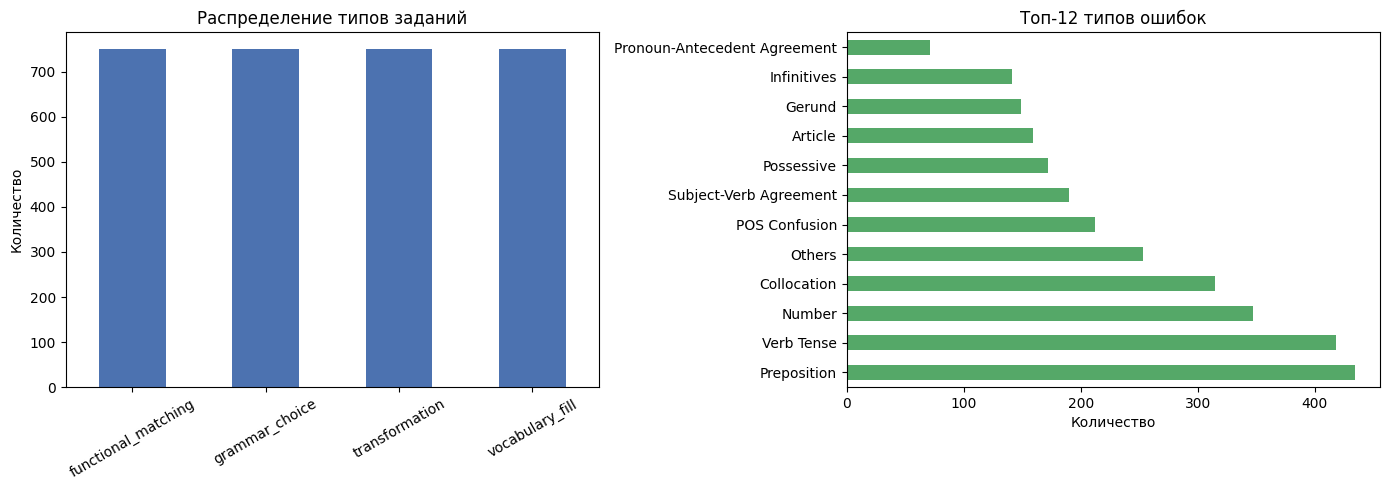

✓ data_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

meta_df["task_type"].value_counts().plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("Распределение типов заданий")
axes[0].set_ylabel("Количество")
axes[0].tick_params(axis='x', rotation=30)

meta_df["error_type"].value_counts().head(12).plot.barh(ax=axes[1], color="#55A868")
axes[1].set_title("Топ-12 типов ошибок")
axes[1].set_xlabel("Количество")

plt.tight_layout()
plt.savefig("data_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ data_distribution.png")

In [ ]:
from sklearn.model_selection import train_test_split

indices = list(range(len(records)))
task_labels = [r["_meta"]["task_type"] for r in records]

train_idx, val_idx = train_test_split(
    indices, test_size=0.1, random_state=SEED, stratify=task_labels
)

def clean_record(record):
    return {"messages": record["messages"]}

train_records = [clean_record(records[i]) for i in train_idx]
val_records   = [clean_record(records[i]) for i in val_idx]
val_meta      = [records[i]["_meta"] for i in val_idx]

print(f"Train: {len(train_records)} | Val: {len(val_records)}")

for path, data in [("train.jsonl", train_records), ("val.jsonl", val_records)]:
    with open(path, "w", encoding="utf-8") as f:
        for r in data:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

with open("val_meta.json", "w", encoding="utf-8") as f:
    json.dump(val_meta, f, ensure_ascii=False, indent=2)

print("✓ train.jsonl, val.jsonl, val_meta.json")

Train: 2700 | Val: 300
✓ train.jsonl, val.jsonl, val_meta.json


## 4. Конфигурация LoRA (fp16)

**Почему fp16 + LoRA (без квантизации):**
- 3B модель в fp16 ≈ 6 ГБ VRAM
- С LoRA-адаптерами + gradient checkpointing ≈ 12–13 ГБ пик
- Не зависим от bitsandbytes и совместимости CUDA-версий

| Параметр | Значение | Обоснование |
|----------|----------|-------------|
| LoRA rank | 64 | Баланс ёмкости/скорости для 3B |
| LoRA alpha | 128 | alpha = 2×rank (стандарт) |
| Target modules | all linear | Максимальная адаптация |
| Batch size | 2 + grad_accum 8 | Эффективный BS=16 |
| Learning rate | 2e-4 | Стандарт для LoRA |
| Epochs | 3 | 3000 samples × 3 epochs |
| Scheduler | cosine | Плавное затухание |

In [ ]:
from dataclasses import dataclass

@dataclass
class TrainConfig:
    # ── LoRA ──────────────────────────────────────────────
    lora_rank: int = 64
    lora_alpha: int = 128
    lora_dropout: float = 0.05

    # ── Training ──────────────────────────────────────────
    num_train_epochs: int = 3
    per_device_train_batch_size: int = 2
    per_device_eval_batch_size: int = 2
    gradient_accumulation_steps: int = 8     
    learning_rate: float = 2e-4
    weight_decay: float = 0.01
    warmup_ratio: float = 0.05
    lr_scheduler_type: str = "cosine"
    max_seq_length: int = 2048

    # ── Logging ───────────────────────────────────────────
    logging_steps: int = 10
    eval_strategy: str = "steps"
    eval_steps: int = 50
    save_strategy: str = "steps"
    save_steps: int = 100
    save_total_limit: int = 2

    # ── Hardware ──────────────────────────────────────────
    bf16: bool = False  
    fp16: bool = True
    seed: int = 42
    gradient_checkpointing: bool = True

cfg = TrainConfig()
print("✓ Конфиг создан")
print(f"  Effective batch size: {cfg.per_device_train_batch_size * cfg.gradient_accumulation_steps}")
print(f"  LoRA: rank={cfg.lora_rank}, alpha={cfg.lora_alpha}")

✓ Конфиг создан
  Effective batch size: 16
  LoRA: rank=64, alpha=128


## 5. Функция обучения

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer, SFTConfig
from datasets import load_dataset
import glob


def load_model(model_name: str, cfg: TrainConfig):
    """Загрузка модели в fp16 + LoRA (без bitsandbytes)."""

    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.pad_token_id = tokenizer.eos_token_id

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        device_map="auto",
        trust_remote_code=True,
        torch_dtype=torch.float16,
    )

    if cfg.gradient_checkpointing:
        model.gradient_checkpointing_enable()
        model.enable_input_require_grads()

    target_modules = set()
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Linear):
            short = name.split(".")[-1]
            if short != "lm_head":
                target_modules.add(short)
    target_modules = sorted(target_modules)

    lora_config = LoraConfig(
        r=cfg.lora_rank,
        lora_alpha=cfg.lora_alpha,
        lora_dropout=cfg.lora_dropout,
        target_modules=target_modules,
        bias="none",
        task_type=TaskType.CAUSAL_LM,
    )

    model = get_peft_model(model, lora_config)

    trainable, total = model.get_nb_trainable_parameters()
    print(f"  Trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")
    print(f"  Target modules: {target_modules}")

    return model, tokenizer


def train_model(model_name: str, cfg: TrainConfig, run_name: str):
    """Полный цикл обучения одной модели."""

    print(f"\n{'='*60}")
    print(f"  ОБУЧЕНИЕ: {model_name}")
    print(f"{'='*60}")

    model, tokenizer = load_model(model_name, cfg)

    dataset = load_dataset("json", data_files={
        "train": "train.jsonl",
        "validation": "val.jsonl",
    })

    def format_chat(example):
        text = tokenizer.apply_chat_template(
            example["messages"], tokenize=False, add_generation_prompt=False
        )
        return {"text": text}

    dataset = dataset.map(format_chat, remove_columns=["messages"])

    sample_len = tokenizer(dataset["train"][0]["text"], return_length=True)["length"][0]
    print(f"  Пример длины: {sample_len} токенов")

    output_dir = f"./checkpoints/{run_name}"

    training_args = SFTConfig(
        output_dir=output_dir,
        num_train_epochs=cfg.num_train_epochs,
        per_device_train_batch_size=cfg.per_device_train_batch_size,
        per_device_eval_batch_size=cfg.per_device_eval_batch_size,
        gradient_accumulation_steps=cfg.gradient_accumulation_steps,
        learning_rate=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
        warmup_ratio=cfg.warmup_ratio,
        lr_scheduler_type=cfg.lr_scheduler_type,
        logging_steps=cfg.logging_steps,
        eval_strategy=cfg.eval_strategy,
        eval_steps=cfg.eval_steps,
        save_strategy=cfg.save_strategy,
        save_steps=cfg.save_steps,
        save_total_limit=cfg.save_total_limit,
        fp16=cfg.fp16,
        bf16=cfg.bf16,
        seed=cfg.seed,
        gradient_checkpointing=cfg.gradient_checkpointing,
        max_seq_length=cfg.max_seq_length,
        dataset_text_field="text",
        report_to="none",
        packing=False,
    )

    trainer = SFTTrainer(
        model=model,
        args=training_args,
        train_dataset=dataset["train"],
        eval_dataset=dataset["validation"],
        processing_class=tokenizer,
    )

    checkpoints = sorted(glob.glob(f"{output_dir}/checkpoint-*"))
    resume_from = checkpoints[-1] if checkpoints else None
    if resume_from:
        print(f"  ⟳ Возобновление с {resume_from}")

    start_time = datetime.now()
    train_result = trainer.train(resume_from_checkpoint=resume_from)
    elapsed = datetime.now() - start_time

    print(f"\n  ✓ Обучение завершено за {elapsed}")
    print(f"  Train loss: {train_result.metrics['train_loss']:.4f}")

    adapter_dir = f"./adapters/{run_name}"
    model.save_pretrained(adapter_dir)
    tokenizer.save_pretrained(adapter_dir)
    print(f"  ✓ Адаптеры → {adapter_dir}")

    log_history = trainer.state.log_history

    del model, trainer
    torch.cuda.empty_cache()

    return adapter_dir, log_history

## 6. Запуск обучения

In [8]:
MODELS = {
    "qwen2.5-3b":  "Qwen/Qwen2.5-3B-Instruct",
    "smollm3-3b":  "HuggingFaceTB/SmolLM3-3B",
    "phi3.5-mini":  "microsoft/Phi-3.5-mini-instruct",
}

results = {}
all_logs = {}

In [ ]:
adapter_dir, logs = train_model(MODELS["qwen2.5-3b"], cfg, "qwen2.5-3b")
results["qwen2.5-3b"] = adapter_dir
all_logs["qwen2.5-3b"] = logs

In [ ]:
adapter_dir, logs = train_model(MODELS["smollm3-3b"], cfg, "smollm3-3b")
results["smollm3-3b"] = adapter_dir
all_logs["smollm3-3b"] = logs

In [ ]:
adapter_dir, logs = train_model(MODELS["phi3.5-mini"], cfg, "phi3.5-mini")
results["phi3.5-mini"] = adapter_dir
all_logs["phi3.5-mini"] = logs

## 7. Кривые обучения

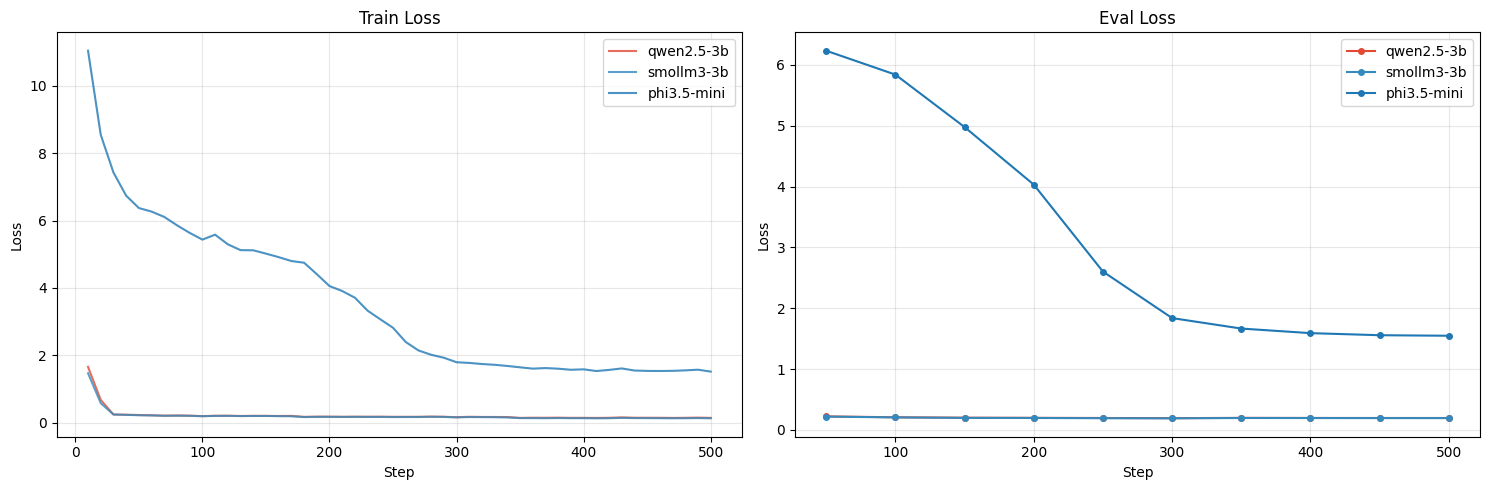

In [12]:
def plot_training_curves(all_logs: dict):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    colors = {"qwen2.5-3b": "#E24A33", "smollm3-3b": "#348ABD", "phi3.5-mini": "#988ED5"}

    for name, logs in all_logs.items():
        train_steps = [l["step"] for l in logs if "loss" in l and "eval_loss" not in l]
        train_loss  = [l["loss"] for l in logs if "loss" in l and "eval_loss" not in l]
        axes[0].plot(train_steps, train_loss, label=name, color=colors.get(name), alpha=0.8)

        eval_steps = [l["step"] for l in logs if "eval_loss" in l]
        eval_loss  = [l["eval_loss"] for l in logs if "eval_loss" in l]
        axes[1].plot(eval_steps, eval_loss, label=name, color=colors.get(name), marker="o", ms=4)

    axes[0].set_title("Train Loss"); axes[0].set_xlabel("Step"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].set_title("Eval Loss"); axes[1].set_xlabel("Step"); axes[1].set_ylabel("Loss")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_training_curves(all_logs)

## 8. Инференс на val-выборке

In [ ]:
from peft import PeftModel


def load_model_for_inference(base_model_name: str, adapter_dir: str):
    """Загрузка base + LoRA для инференса (fp16, без bitsandbytes)."""

    tokenizer = AutoTokenizer.from_pretrained(adapter_dir, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    base_model = AutoModelForCausalLM.from_pretrained(
        base_model_name,
        device_map="auto",
        trust_remote_code=True,
        torch_dtype=torch.float16,
    )

    model = PeftModel.from_pretrained(base_model, adapter_dir)
    model.eval()
    return model, tokenizer


def generate_responses(model, tokenizer, val_records, max_new_tokens=2048):
    """Генерация ответов (greedy decoding)."""
    predictions = []

    for i, rec in enumerate(val_records):
        messages = rec["messages"][:2]  

        prompt = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )

        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048)
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                temperature=1.0,
                pad_token_id=tokenizer.pad_token_id,
            )

        gen_ids = output_ids[0][inputs["input_ids"].shape[1]:]
        prediction = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()
        predictions.append(prediction)

        if (i + 1) % 50 == 0:
            print(f"  [{i+1}/{len(val_records)}]")

    return predictions

In [ ]:
val_records = []
with open("val.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        val_records.append(json.loads(line))

with open("val_meta.json", "r", encoding="utf-8") as f:
    val_meta = json.load(f)

references = [r["messages"][2]["content"] for r in val_records]
print(f"Val записей: {len(val_records)}")

Val записей: 300


In [18]:
val_records_small = val_records[:50]
val_meta_small = val_meta[:50]
references_small = [r["messages"][2]["content"] for r in val_records_small]

print(f"Val сокращён: {len(val_records_small)} примеров")

Val сокращён: 50 примеров


In [ ]:
from tqdm import tqdm
import shutil, gc

HF_CACHE = os.path.expanduser("~/.cache/huggingface/hub")
all_predictions = {}

for name, base_name in MODELS.items():
    print(f"\n{'='*50}")
    print(f"  Инференс: {name}")
    print(f"{'='*50}")

    if os.path.exists(HF_CACHE):
        shutil.rmtree(HF_CACHE)
        print("  ✗ HF cache очищен")

    adapter_dir = results[name]
    model, tokenizer = load_model_for_inference(base_name, adapter_dir)

    predictions = []
    for rec in tqdm(val_records_small, desc=f"  {name}", unit="ex"):
        messages = rec["messages"][:2]
        prompt = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048)
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=2048,
                do_sample=False,
                temperature=1.0,
                pad_token_id=tokenizer.pad_token_id,
            )

        gen_ids = output_ids[0][inputs["input_ids"].shape[1]:]
        predictions.append(tokenizer.decode(gen_ids, skip_special_tokens=True).strip())

    all_predictions[name] = predictions
    print(f"  ✓ {len(predictions)} предсказаний")

    del model, tokenizer
    gc.collect()
    torch.cuda.empty_cache()

with open("all_predictions.json", "w", encoding="utf-8") as f:
    json.dump(all_predictions, f, ensure_ascii=False, indent=2)
print("\n✓ all_predictions.json")

In [ ]:
# ── Дозапуск только Phi ───────────────────────────────────
if os.path.exists(HF_CACHE):
    shutil.rmtree(HF_CACHE)

tokenizer = AutoTokenizer.from_pretrained(results["phi3.5-mini"], trust_remote_code=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    MODELS["phi3.5-mini"],
    device_map="auto",
    trust_remote_code=False,        
    torch_dtype=torch.float16,
    attn_implementation="eager",    
)
model = PeftModel.from_pretrained(base_model, results["phi3.5-mini"])
model.eval()

predictions = []
for rec in tqdm(val_records_small, desc="  phi3.5-mini", unit="ex"):
    messages = rec["messages"][:2]
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=2048,
            do_sample=False,
            temperature=1.0,
            pad_token_id=tokenizer.pad_token_id,
        )

    gen_ids = output_ids[0][inputs["input_ids"].shape[1]:]
    predictions.append(tokenizer.decode(gen_ids, skip_special_tokens=True).strip())

all_predictions["phi3.5-mini"] = predictions
print(f"  ✓ {len(predictions)} предсказаний")

del model, base_model, tokenizer
gc.collect()
torch.cuda.empty_cache()

with open("all_predictions.json", "w", encoding="utf-8") as f:
    json.dump(all_predictions, f, ensure_ascii=False, indent=2)
print("✓ all_predictions.json")

  phi3.5-mini: 100%|██████████| 50/50 [17:02<00:00, 20.46s/ex]


  ✓ 50 предсказаний
✓ all_predictions.json


## 9. Оценка качества

| Метрика | Что измеряет | Интерпретация |
|---------|-------------|---------------|
| **BERTScore F1** | Семантическое сходство с референсом | 0→1, выше лучше |
| **Perplexity** | Уверенность модели на val-сете | Ниже лучше |
| **Task-Relevance** | Структурная корректность + соответствие заданию | 0→1, выше лучше |

In [ ]:
from bert_score import score as bert_score_fn

def compute_bertscore(predictions: list, references: list, chunk_size=3000):
    """BERTScore по чанкам — без потери текста."""
    f1_scores = []

    for pred, ref in zip(predictions, references):
        pred_chunks = [pred[i:i+chunk_size] for i in range(0, max(len(pred), 1), chunk_size)]
        ref_chunks  = [ref[i:i+chunk_size] for i in range(0, max(len(ref), 1), chunk_size)]

        n = min(len(pred_chunks), len(ref_chunks))
        if n == 0:
            continue

        P, R, F1 = bert_score_fn(
            pred_chunks[:n], ref_chunks[:n],
            model_type="distilbert-base-uncased",
            lang="en", verbose=False, batch_size=8,
        )
        f1_scores.append(F1.mean().item())

    f1_arr = np.array(f1_scores)
    return {
        "f1":      f1_arr.mean(),
        "f1_std":  f1_arr.std(),
    }

bertscore_results = {}
for name, preds in all_predictions.items():
    print(f"BERTScore для {name}...")
    bertscore_results[name] = compute_bertscore(preds, references_small)
    # bertscore_results[name] = compute_bertscore(preds, references)
    print(f"  F1 = {bertscore_results[name]['f1']:.4f} ± {bertscore_results[name]['f1_std']:.4f}")

In [ ]:
perplexity_results = {}

for name in ["qwen2.5-3b", "smollm3-3b"]:
    print(f"\nPerplexity для {name}...")
    
    if os.path.exists(HF_CACHE):
        shutil.rmtree(HF_CACHE)
    
    tokenizer = AutoTokenizer.from_pretrained(results[name], trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    base_model = AutoModelForCausalLM.from_pretrained(
        MODELS[name],
        device_map="auto",
        trust_remote_code=True,
        torch_dtype=torch.float16,
    )
    model = PeftModel.from_pretrained(base_model, results[name])
    model.eval()

    total_loss = 0.0
    total_tokens = 0
    for rec in val_records_small:
        text = tokenizer.apply_chat_template(
            rec["messages"], tokenize=False, add_generation_prompt=False
        )
        enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=2048)
        input_ids = enc["input_ids"].to(model.device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, labels=input_ids)
            total_loss += outputs.loss.item() * input_ids.shape[1]
            total_tokens += input_ids.shape[1]

    ppl = np.exp(total_loss / total_tokens)
    perplexity_results[name] = {"perplexity": ppl, "avg_loss": total_loss / total_tokens}
    print(f"  PPL = {ppl:.2f}")

    del model, base_model, tokenizer
    gc.collect()
    torch.cuda.empty_cache()


Perplexity для qwen2.5-3b...


Loading weights: 100%|██████████| 434/434 [00:06<00:00, 64.44it/s]


  PPL = 1.21

Perplexity для smollm3-3b...


Loading weights: 100%|██████████| 326/326 [00:05<00:00, 63.88it/s]


  PPL = 1.23


In [ ]:
if os.path.exists(HF_CACHE):
    shutil.rmtree(HF_CACHE)

tokenizer = AutoTokenizer.from_pretrained(results["phi3.5-mini"], trust_remote_code=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    MODELS["phi3.5-mini"],
    device_map={"": 0},           
    trust_remote_code=False,
    torch_dtype=torch.float16,
    attn_implementation="eager",
)
model = PeftModel.from_pretrained(base_model, results["phi3.5-mini"])
model.eval()

total_loss = 0.0
total_tokens = 0
for rec in val_records_small:
    text = tokenizer.apply_chat_template(
        rec["messages"], tokenize=False, add_generation_prompt=False
    )
    enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=2048)
    input_ids = enc["input_ids"].to(model.device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, labels=input_ids)
        total_loss += outputs.loss.item() * input_ids.shape[1]
        total_tokens += input_ids.shape[1]

ppl = np.exp(total_loss / total_tokens)
perplexity_results["phi3.5-mini"] = {"perplexity": ppl, "avg_loss": total_loss / total_tokens}
print(f"  PPL = {ppl:.2f}")

del model, base_model, tokenizer
gc.collect()
torch.cuda.empty_cache()

Loading weights: 100%|██████████| 195/195 [00:05<00:00, 33.51it/s]


  PPL = 5.29


In [ ]:
VALID_TASK_TYPES = {
    "vocabulary_fill", "matching", "grammar_choice", "transformation",
    "reading_tf", "functional_match", "functional_matching", "writing_sample",
}

ITEM_COUNT_RANGES = {
    "grammar_choice":      (10, 14),
    "transformation":      (8, 12),
    "vocabulary_fill":     (8, 20),
    "functional_match":    (8, 10),
    "functional_matching": (8, 10),
    "matching":            (8, 12),
    "reading_tf":          (6, 10),
    "writing_sample":      (1, 3),
}

def evaluate_task_relevance(predictions: list, val_meta: list):
    """
    Проверяет:
    1. json_valid        — парсится ли JSON
    2. task_type_match   — тип задания совпадает
    3. error_cat_present — категория ошибки заполнена
    4. items_count_ok    — items в допустимом диапазоне
    5. has_answers       — все items содержат student_answer_en
    """
    metrics = {k: 0 for k in [
        "json_valid", "task_type_match", "error_cat_present",
        "items_count_ok", "has_answers"
    ]}
    total = len(predictions)

    for pred, meta in zip(predictions, val_meta):
        try:
            raw = pred.strip()
            if raw.startswith("```"):
                raw = raw.split("```")[1]
                if raw.startswith("json"):
                    raw = raw[4:]
            data = json.loads(raw)
        except (json.JSONDecodeError, IndexError):
            continue

        metrics["json_valid"] += 1

        requested = meta.get("task_type", "")
        generated = data.get("task", {}).get("type", "")
        if generated.replace("_", "") == requested.replace("_", ""):
            metrics["task_type_match"] += 1

        cat = data.get("target_error_category", "")
        if cat and len(cat) > 1:
            metrics["error_cat_present"] += 1

        items = data.get("task", {}).get("content_en", {}).get("items", [])
        lo, hi = ITEM_COUNT_RANGES.get(generated, (1, 30))
        if lo <= len(items) <= hi:
            metrics["items_count_ok"] += 1

        if items and all(item.get("student_answer_en") for item in items):
            metrics["has_answers"] += 1

    rates = {k: v / total for k, v in metrics.items()}
    rates["composite"] = np.mean(list(rates.values()))
    rates["_total"] = total

    return rates

task_relevance_results = {}
for name, preds in all_predictions.items():
    print(f"\nTask-Relevance для {name}:")
    # tr = evaluate_task_relevance(preds, val_meta)
    tr = evaluate_task_relevance(preds, val_meta_small)
    task_relevance_results[name] = tr
    for k, v in tr.items():
        if not k.startswith("_"):
            print(f"  {k}: {v:.1%}")


Task-Relevance для qwen2.5-3b:
  json_valid: 100.0%
  task_type_match: 86.0%
  error_cat_present: 100.0%
  items_count_ok: 96.0%
  has_answers: 96.0%
  composite: 95.6%

Task-Relevance для smollm3-3b:
  json_valid: 98.0%
  task_type_match: 84.0%
  error_cat_present: 98.0%
  items_count_ok: 88.0%
  has_answers: 94.0%
  composite: 92.4%

Task-Relevance для phi3.5-mini:
  json_valid: 94.0%
  task_type_match: 94.0%
  error_cat_present: 94.0%
  items_count_ok: 2.0%
  has_answers: 94.0%
  composite: 75.6%


## 10. Сводная таблица и визуализация

In [40]:
rows = []
for name in MODELS.keys():
    rows.append({
        "Модель": name,
        "BERTScore F1": f"{bertscore_results[name]['f1']:.4f}",
        "Perplexity": f"{perplexity_results[name]['perplexity']:.2f}",
        "JSON Valid": f"{task_relevance_results[name]['json_valid']:.1%}",
        "Task Match": f"{task_relevance_results[name]['task_type_match']:.1%}",
        "Items OK": f"{task_relevance_results[name]['items_count_ok']:.1%}",
        "Answers OK": f"{task_relevance_results[name]['has_answers']:.1%}",
        "TR Composite": f"{task_relevance_results[name]['composite']:.1%}",
    })

comparison_df = pd.DataFrame(rows).set_index("Модель")
print(comparison_df.to_string())
comparison_df.to_csv("model_comparison.csv")
print("\n✓ model_comparison.csv")

            BERTScore F1 Perplexity JSON Valid Task Match Items OK Answers OK TR Composite
Модель                                                                                    
qwen2.5-3b        0.9037       1.21     100.0%      86.0%    96.0%      96.0%        95.6%
smollm3-3b        0.9033       1.23      98.0%      84.0%    88.0%      94.0%        92.4%
phi3.5-mini       0.8799       5.29      94.0%      94.0%     2.0%      94.0%        75.6%

✓ model_comparison.csv


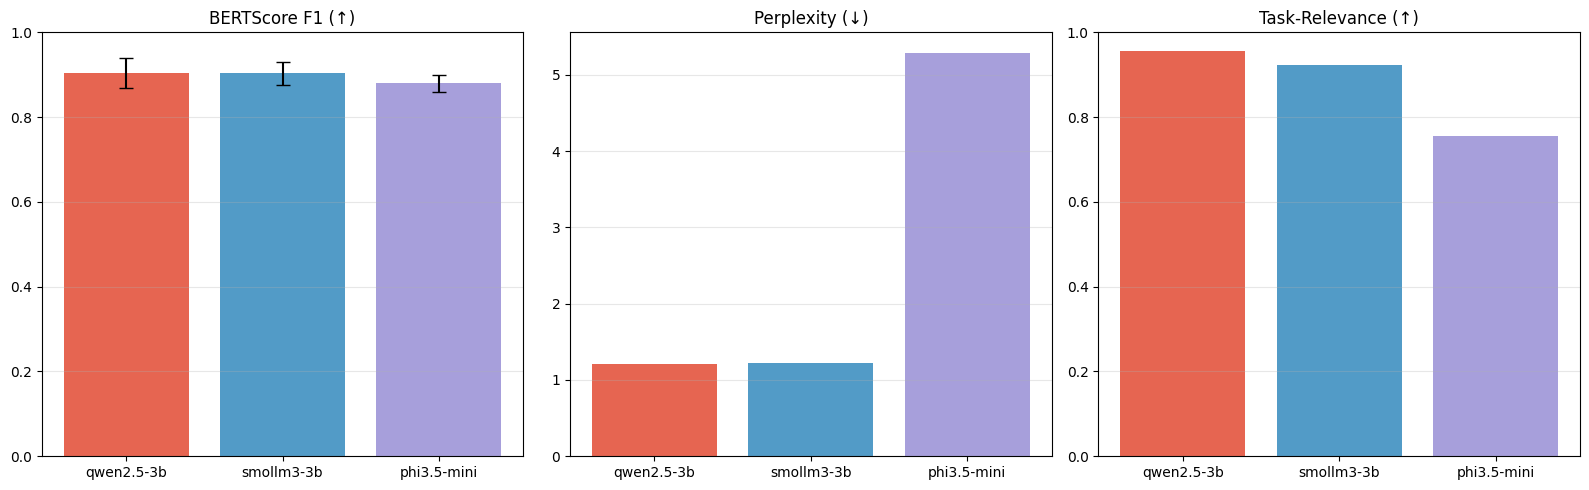

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
names = list(MODELS.keys())
colors = ["#E24A33", "#348ABD", "#988ED5"]

vals = [bertscore_results[n]["f1"] for n in names]
stds = [bertscore_results[n]["f1_std"] for n in names]
axes[0].bar(names, vals, yerr=stds, color=colors, alpha=0.85, capsize=5)
axes[0].set_title("BERTScore F1 (↑)"); axes[0].set_ylim(0, 1); axes[0].grid(axis="y", alpha=0.3)

vals = [perplexity_results[n]["perplexity"] for n in names]
axes[1].bar(names, vals, color=colors, alpha=0.85)
axes[1].set_title("Perplexity (↓)"); axes[1].grid(axis="y", alpha=0.3)

vals = [task_relevance_results[n]["composite"] for n in names]
axes[2].bar(names, vals, color=colors, alpha=0.85)
axes[2].set_title("Task-Relevance (↑)"); axes[2].set_ylim(0, 1); axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Примеры генерации

In [42]:
for name in MODELS.keys():
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")

    for i in [0, 1]:
        meta = val_meta[i]
        pred = all_predictions[name][i]

        print(f"\n--- Пример {i+1} ---")
        print(f"Задание: {meta['task_type']} | Ошибка: {meta['error_type']}")
        print(f"Source: {meta['source']}...")

        try:
            parsed = json.loads(pred)
            items = parsed.get("task", {}).get("content_en", {}).get("items", [])
            print(f"Тип: {parsed.get('task', {}).get('type', 'N/A')} | Items: {len(items)}")
            if items:
                print(f"Item 1: {items[0].get('question_en', '')}...")
        except:
            print(f"[Parse error] {pred[:120]}...")


  qwen2.5-3b

--- Пример 1 ---
Задание: vocabulary_fill | Ошибка: Preposition
Source: I live in a small town called Grycksbo and I've been part of Unga Kris volunteering programs since the summer 2010....
Тип: vocabulary_fill | Items: 10
Item 1: I moved here last year and I’ve really enjoyed living in the ___ quiet countryside....

--- Пример 2 ---
Задание: vocabulary_fill | Ошибка: Subject-Verb Agreement
Source: Science practically improve our lives....
Тип: vocabulary_fill | Items: 11
Item 1: I wanted to share some thoughts about how science ___ our daily lives in so many ways....

  smollm3-3b

--- Пример 1 ---
Задание: vocabulary_fill | Ошибка: Preposition
Source: I live in a small town called Grycksbo and I've been part of Unga Kris volunteering programs since the summer 2010....
Тип: vocabulary_fill | Items: 15
Item 1: I ___ in a small town, and it's been a great experience to be involved in local community projects....

--- Пример 2 ---
Задание: vocabulary_fill | Ошибка: Subjec

## 12. Сохранение отчёта

In [ ]:
report = {
    "date": datetime.now().isoformat(),
    "method": "LoRA fp16 (no quantization)",
    "config": {
        "lora_rank": cfg.lora_rank,
        "lora_alpha": cfg.lora_alpha,
        "epochs": cfg.num_train_epochs,
        "effective_bs": cfg.per_device_train_batch_size * cfg.gradient_accumulation_steps,
        "lr": cfg.learning_rate,
        "max_seq_length": cfg.max_seq_length,
        "train_n": len(train_records),
        "val_n": len(val_records),
    },
    "models": {
        name: {
            "base": MODELS[name],
            "adapter_dir": results[name],
            "bertscore": bertscore_results[name],
            "perplexity": perplexity_results[name],
            "task_relevance": task_relevance_results[name],
        }
        for name in MODELS.keys()
    },
}

with open("experiment_report.json", "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print("✓ experiment_report.json")
print("\nАртефакты:")
print("  • train.jsonl / val.jsonl — данные")
print("  • ./adapters/*/  — LoRA-адаптеры 3 моделей")
print("  • all_predictions.json — генерации на val-сете")
print("  • experiment_report.json — все метрики")
print("  • model_comparison.csv — сводная таблица")
print("  • training_curves.png / model_comparison.png / data_distribution.png")